image

Original shape: (4, 4)


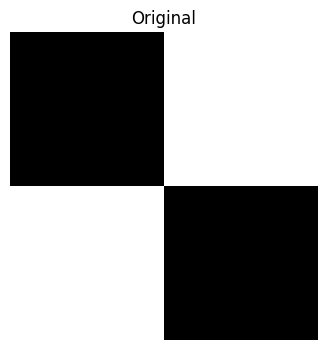

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = np.array([
    [0,   0,   255, 255],
    [0,   0,   255, 255],
    [255, 255, 0,   0  ],
    [255, 255, 0,   0  ]
], dtype=np.uint8)

print("Original shape:", image.shape)

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")
plt.show()

Nearest Neighbor

In [2]:
nearest = cv2.resize(
    image,
    (200, 200),
    interpolation=cv2.INTER_NEAREST
)

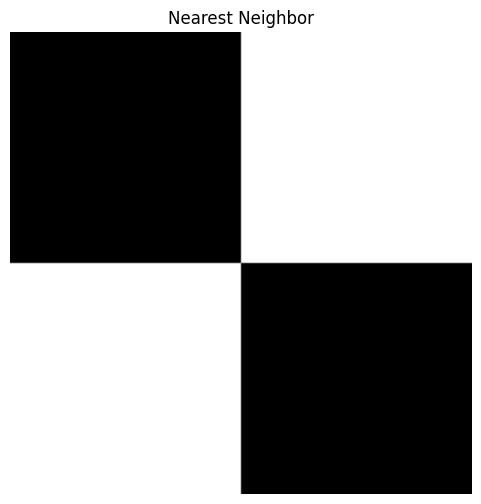

In [3]:
plt.figure(figsize=(6, 6))
plt.imshow(nearest, cmap="gray", vmin=0, vmax=255)
plt.title("Nearest Neighbor")
plt.axis("off")
plt.show()

Bilinear

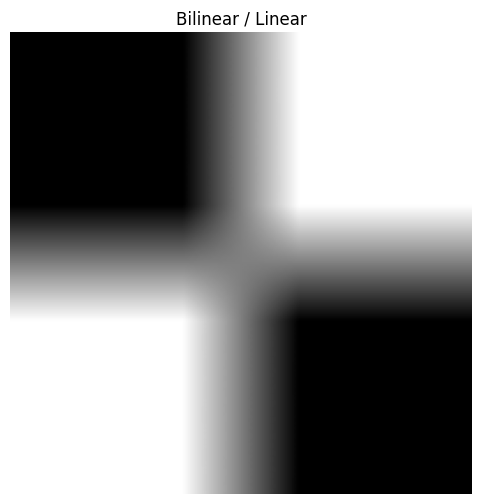

In [4]:
linear = cv2.resize(
    image,
    (200, 200),
    interpolation=cv2.INTER_LINEAR
)

plt.figure(figsize=(6, 6))
plt.imshow(linear, cmap="gray", vmin=0, vmax=255)
plt.title("Bilinear / Linear")
plt.axis("off")
plt.show()

Bicubic

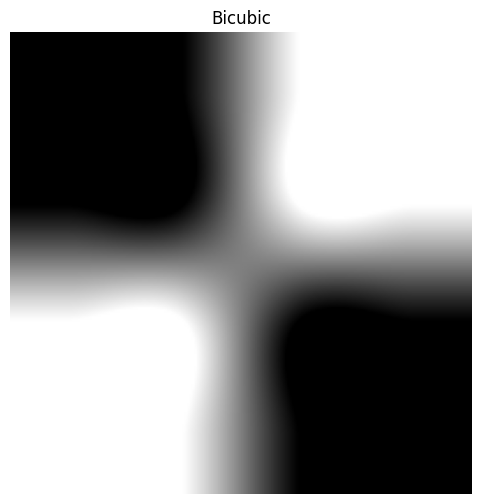

In [5]:
cubic = cv2.resize(
    image,
    (200, 200),
    interpolation=cv2.INTER_CUBIC
)

plt.figure(figsize=(6, 6))
plt.imshow(cubic, cmap="gray", vmin=0, vmax=255)
plt.title("Bicubic")
plt.axis("off")
plt.show()

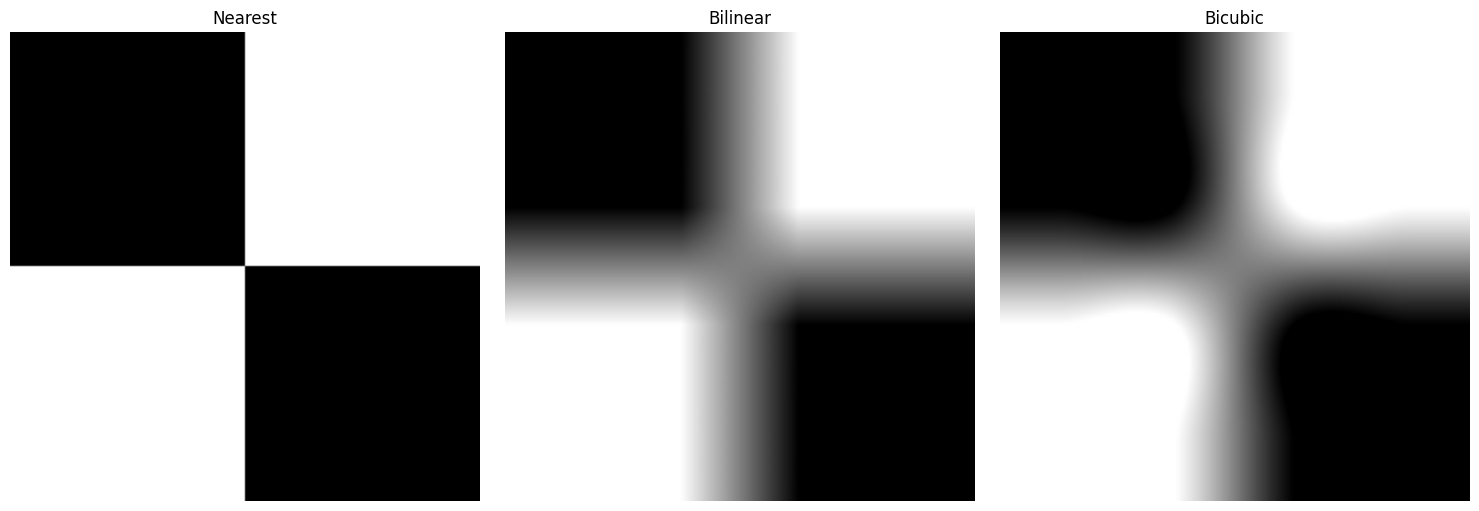

In [6]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(nearest, cmap="gray", vmin=0, vmax=255)
plt.title("Nearest")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(linear, cmap="gray", vmin=0, vmax=255)
plt.title("Bilinear")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cubic, cmap="gray", vmin=0, vmax=255)
plt.title("Bicubic")
plt.axis("off")

plt.tight_layout()
plt.show()

# Mask

In [7]:
mask = np.array([
    [0, 0, 1, 1],
    [0, 0, 1, 1],
    [1, 1, 0, 0],
    [1, 1, 0, 0]
], dtype=np.uint8)

Nearest

In [8]:
mask_nearest = cv2.resize(
    mask,
    (200, 200),
    interpolation=cv2.INTER_NEAREST
)

Bilinear

In [9]:
mask_linear = cv2.resize(
    mask,
    (200, 200),
    interpolation=cv2.INTER_LINEAR
)

In [10]:
print("Nearest unique values:")
print(np.unique(mask_nearest))

print("Linear unique values:")
print(np.unique(mask_linear))

Nearest unique values:
[0 1]
Linear unique values:
[0 1]


# Direct Resize

In [12]:
image = cv2.imread("/content/flowers.jpg")

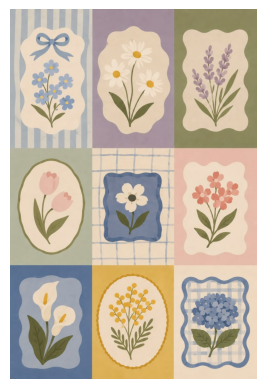

In [13]:
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis("off");

In [18]:
image.shape

(300, 500)

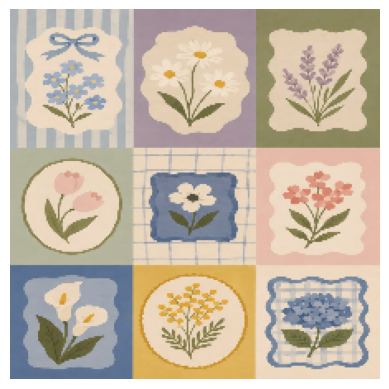

In [14]:
resized = cv2.resize(
    image,
    (224, 224),
    interpolation=cv2.INTER_LINEAR
)

plt.imshow(resized)
plt.axis("off");

Crop

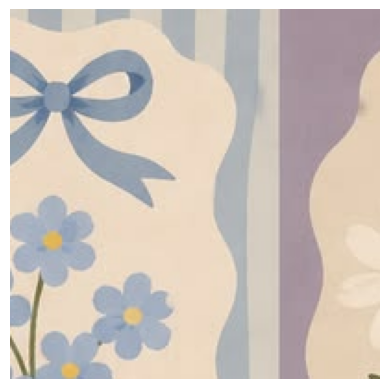

In [15]:
crop = image[50:250, 100:300]
plt.imshow(crop)
plt.axis("off");

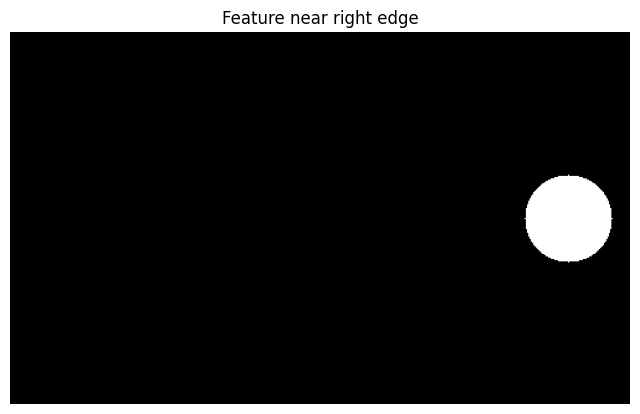

In [21]:
image = np.zeros((300, 500), dtype=np.uint8)

cv2.circle(
    image,
    (450, 150),
    35,
    255,
    -1
)

plt.figure(figsize=(8, 5))
plt.imshow(image, cmap="gray")
plt.title("Feature near right edge")
plt.axis("off")
plt.show()

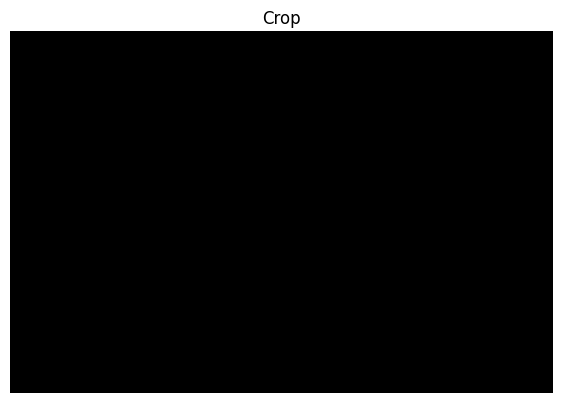

In [22]:
crop = image[
    50:250,
    100:400
]

plt.figure(figsize=(7, 5))
plt.imshow(crop, cmap="gray")
plt.title("Crop")
plt.axis("off")
plt.show()

synthetic

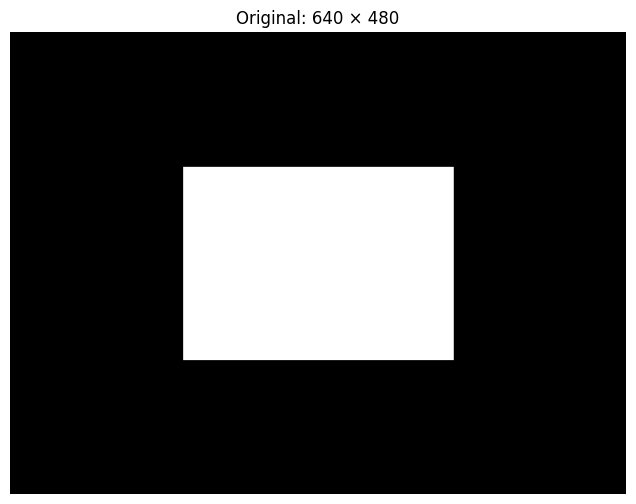

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = np.zeros((480, 640), dtype=np.uint8)

cv2.rectangle(
    image,
    (180, 140),
    (460, 340),
    255,
    -1
)

plt.figure(figsize=(8, 6))
plt.imshow(image, cmap="gray", vmin=0, vmax=255)
plt.title("Original: 640 × 480")
plt.axis("off")
plt.show()

scale

In [24]:
target_w = 512
target_h = 512

h, w = image.shape[:2]

scale = min(
    target_w / w,
    target_h / h
)

print("scale:", scale)

scale: 0.8


In [25]:
new_w = round(w * scale)
new_h = round(h * scale)

print("new size:", new_w, new_h)

new size: 512 384


Resize

In [26]:
resized = cv2.resize(
    image,
    (new_w, new_h),
    interpolation=cv2.INTER_LINEAR
)

Padding

In [27]:
pad_w = target_w - new_w
pad_h = target_h - new_h

print("pad_w:", pad_w)
print("pad_h:", pad_h)

pad_w: 0
pad_h: 128


In [28]:
top = pad_h // 2
bottom = pad_h - top

left = pad_w // 2
right = pad_w - left

print(top, bottom, left, right)

64 64 0 0


In [29]:
letterboxed = cv2.copyMakeBorder(
    resized,
    top,
    bottom,
    left,
    right,
    borderType=cv2.BORDER_CONSTANT,
    value=0
)

In [30]:
print("Original:", image.shape)
print("Resized:", resized.shape)
print("Letterboxed:", letterboxed.shape)

Original: (480, 640)
Resized: (384, 512)
Letterboxed: (512, 512)


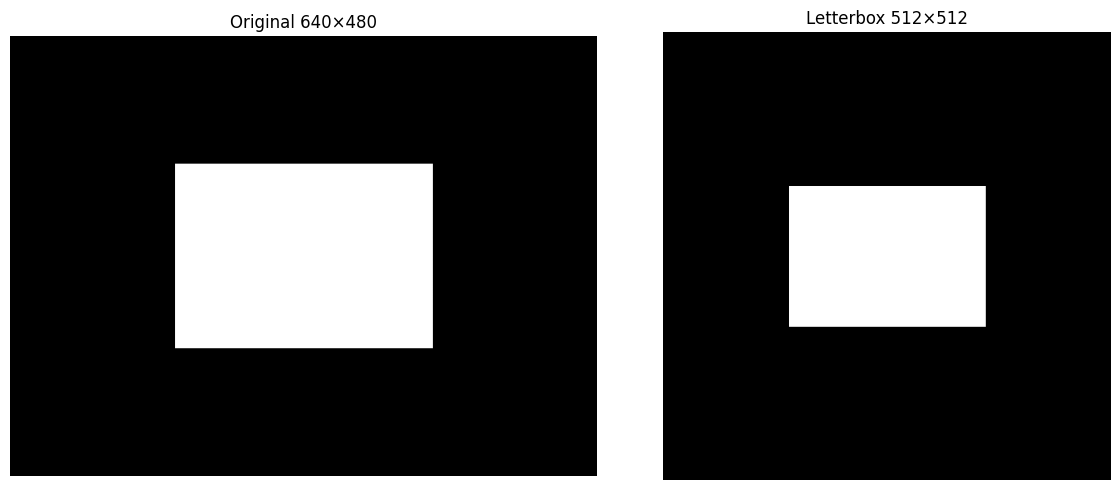

In [31]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original 640×480")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(letterboxed, cmap="gray")
plt.title("Letterbox 512×512")
plt.axis("off")

plt.tight_layout()
plt.show()

# Wound-at-Edge Simulation

Synthetic Image

In [32]:
def make_target_image(position):
    image = np.zeros((400, 600), dtype=np.uint8)

    positions = {
        "left":   (25, 200),
        "right":  (575, 200),
        "top":    (300, 25),
        "bottom": (300, 375),
        "center": (300, 200),
    }

    x, y = positions[position]

    cv2.circle(
        image,
        (x, y),
        20,
        255,
        -1
    )

    return image

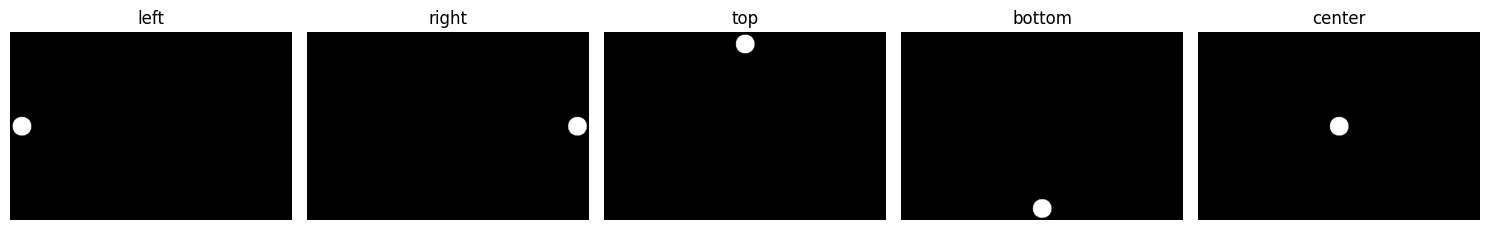

In [33]:
positions = [
    "left",
    "right",
    "top",
    "bottom",
    "center"
]

plt.figure(figsize=(15, 8))

for i, position in enumerate(positions, start=1):
    img = make_target_image(position)

    plt.subplot(1, 5, i)
    plt.imshow(img, cmap="gray")
    plt.title(position)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [34]:
def target_area(image):
    return np.sum(image == 255)

Crop Simulation

In [35]:
def center_crop(image, crop_h, crop_w):
    h, w = image.shape[:2]

    y1 = (h - crop_h) // 2
    x1 = (w - crop_w) // 2

    y2 = y1 + crop_h
    x2 = x1 + crop_w

    return image[y1:y2, x1:x2]

In [36]:
crop = center_crop(
    image,
    crop_h=300,
    crop_w=400
)

In [37]:
results = []

for position in positions:

    original = make_target_image(position)

    cropped = center_crop(
        original,
        crop_h=300,
        crop_w=400
    )

    original_area = target_area(original)
    cropped_area = target_area(cropped)

    results.append({
        "position": position,
        "original_area": original_area,
        "cropped_area": cropped_area,
    })

results

[{'position': 'left',
  'original_area': np.int64(1257),
  'cropped_area': np.int64(0)},
 {'position': 'right',
  'original_area': np.int64(1257),
  'cropped_area': np.int64(0)},
 {'position': 'top',
  'original_area': np.int64(1257),
  'cropped_area': np.int64(0)},
 {'position': 'bottom',
  'original_area': np.int64(1257),
  'cropped_area': np.int64(0)},
 {'position': 'center',
  'original_area': np.int64(1257),
  'cropped_area': np.int64(1257)}]

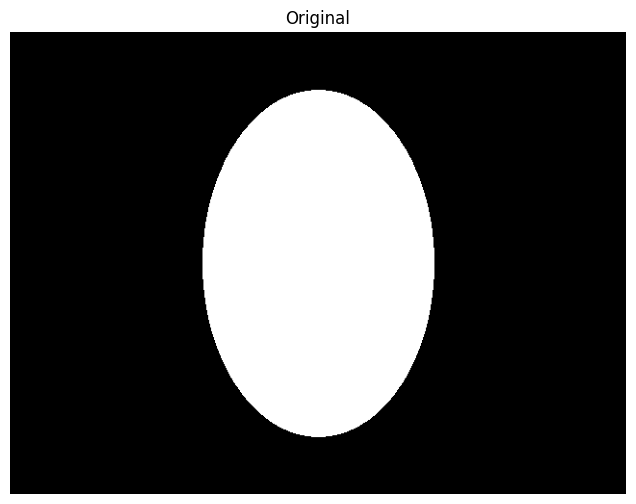

In [38]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = np.zeros((480, 640), dtype=np.uint8)

cv2.ellipse(
    image,
    center=(320, 240),
    axes=(120, 180),
    angle=0,
    startAngle=0,
    endAngle=360,
    color=255,
    thickness=-1
)

plt.figure(figsize=(8, 6))
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")
plt.show()

Direct Resize

In [39]:
direct = cv2.resize(
    image,
    (224, 224),
    interpolation=cv2.INTER_LINEAR
)

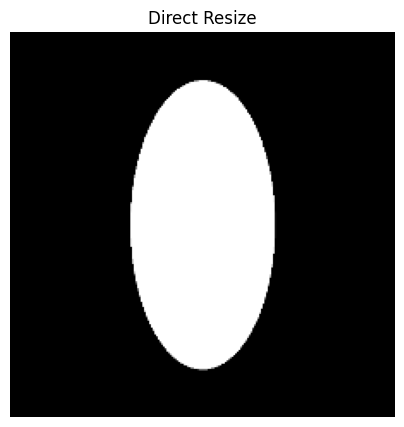

In [40]:
plt.figure(figsize=(5, 5))
plt.imshow(direct, cmap="gray")
plt.title("Direct Resize")
plt.axis("off")
plt.show()

In [41]:
target_w = 224
target_h = 224

h, w = image.shape[:2]

scale = min(
    target_w / w,
    target_h / h
)

new_w = round(w * scale)
new_h = round(h * scale)

resized = cv2.resize(
    image,
    (new_w, new_h),
    interpolation=cv2.INTER_LINEAR
)

pad_w = target_w - new_w
pad_h = target_h - new_h

left = pad_w // 2
right = pad_w - left

top = pad_h // 2
bottom = pad_h - top

letterboxed = cv2.copyMakeBorder(
    resized,
    top,
    bottom,
    left,
    right,
    cv2.BORDER_CONSTANT,
    value=0
)

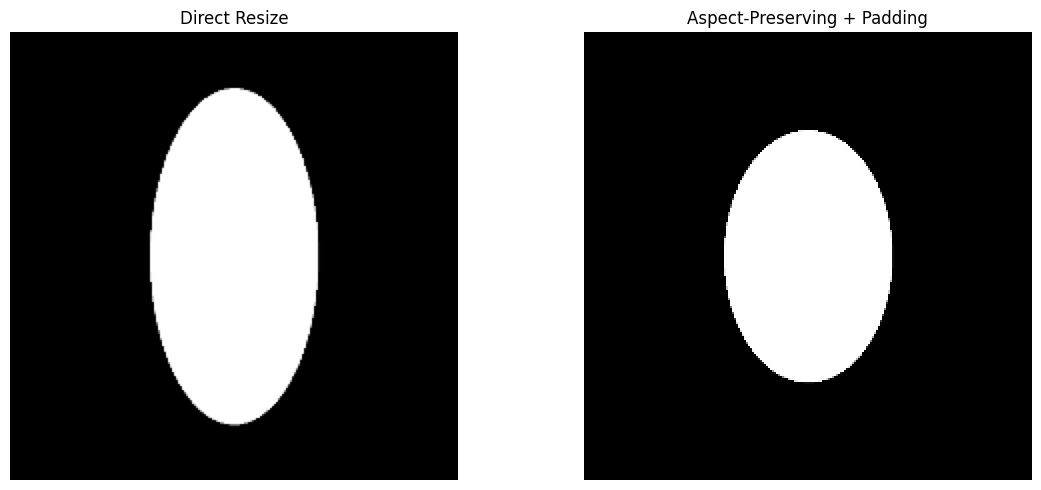

In [42]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(direct, cmap="gray")
plt.title("Direct Resize")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(letterboxed, cmap="gray")
plt.title("Aspect-Preserving + Padding")
plt.axis("off")

plt.tight_layout()
plt.show()